In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from datetime import datetime
from scipy.stats import chi2_contingency

# Analyse Descriptive

In [3]:
df = pd.read_excel('data/working_dataset.xlsx')

In [5]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.head(3)

,DATE_OPERATION,INDLIB_GROUPE,PORTEF,MONTANT,DUREE,PERIODE,TAUX_INT,NB_ECH,SEX,A_GARANTIE,AGENCE_LIEU,IMPAYE,NBIMP,MNTREMB,AGE,ETATCIVIL,WILAYA_NAISSANCE,TYPE_CLIENT,DEFAUT
0,2013-07-18,Services,DDC,2500000.0,48,T,5.0,16,Male,Non,Nouakchott,0.0,0,180785.84,55,Married,Adrar,Public,0
1,2013-07-21,Commerce,DDC,2500000.0,48,T,5.0,16,Male,Non,Nouakchott,0.0,0,180785.84,67,Single,Inconnu,Public,0
2,2013-07-21,Services,DDC,2500000.0,48,T,5.0,16,Male,Non,Nouakchott,0.0,0,180785.84,58,Married,Adrar,Public,0


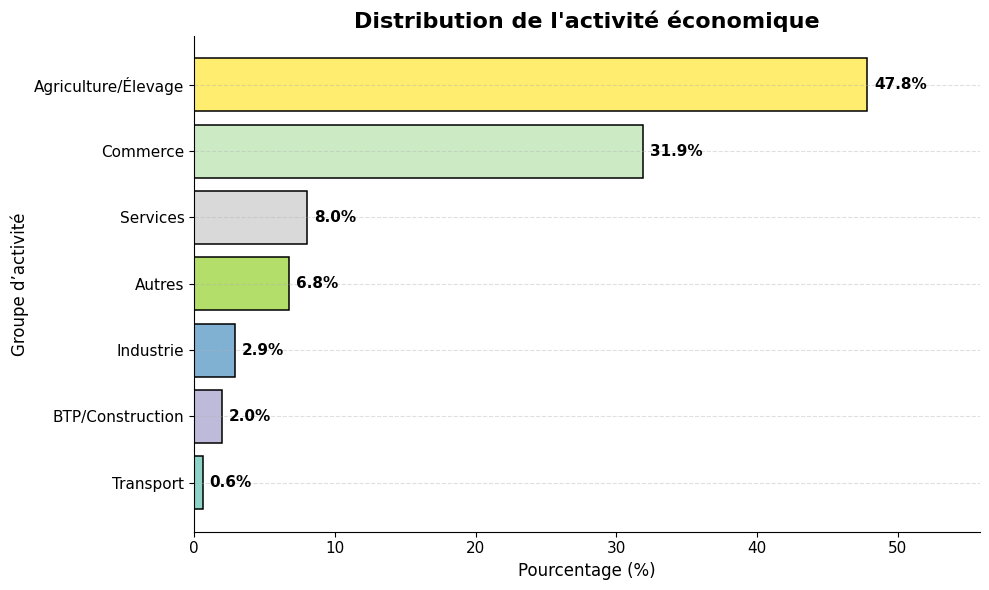

In [6]:
# Calcul des pourcentages
data = (
    df['INDLIB_GROUPE']
    .value_counts(normalize=True)
    .mul(100)
    .sort_values(ascending=True)   # ascending=True pour un beau graphique horizontal
)

# Palette de couleurs
colors = plt.cm.Set3(np.linspace(0, 1, len(data)))

# Création du graphique
plt.figure(figsize=(10, 6))

bars = plt.barh(
    data.index,
    data.values,
    color=colors,
    edgecolor='black',
    linewidth=1.1
)

# Ajouter les pourcentages au bout des barres
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.1f}%',
        va='center',
        fontsize=11,
        fontweight='bold'
    )

# Personnalisation
plt.title("Distribution de l'activité économique", fontsize=16, fontweight='bold')
plt.xlabel('Pourcentage (%)', fontsize=12)
plt.ylabel('Groupe d’activité', fontsize=12)

plt.xlim(0, data.max() + 8)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.4)

# Supprimer les bordures inutiles
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### PORTEF

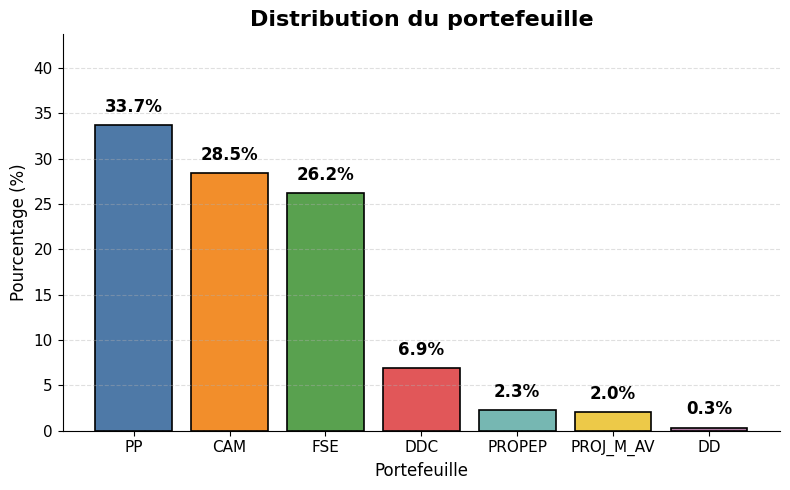

In [7]:
# Calcul des pourcentages
data = df['PORTEF'].value_counts(normalize=True).mul(100).sort_values(ascending=False)

# Une couleur différente pour chaque barre
colors = [
    '#4E79A7',  # bleu
    '#F28E2B',  # orange
    '#59A14F',  # vert
    '#E15759',  # rouge
    '#76B7B2',  # turquoise
    '#EDC948',  # jaune
    '#B07AA1'   # violet
]

# Création du graphique
plt.figure(figsize=(8, 5))

bars = plt.bar(
    data.index,
    data.values,
    color=colors[:len(data)],
    edgecolor='black',
    linewidth=1.2
)

# Ajouter les pourcentages au-dessus des barres
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

# Personnalisation
plt.title('Distribution du portefeuille', fontsize=16, fontweight='bold')
plt.xlabel('Portefeuille', fontsize=12)
plt.ylabel('Pourcentage (%)', fontsize=12)

plt.ylim(0, data.max() + 10)
plt.xticks(rotation=0, fontsize=11)
plt.yticks(fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.4)

# Supprimer les bordures inutiles
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Montant

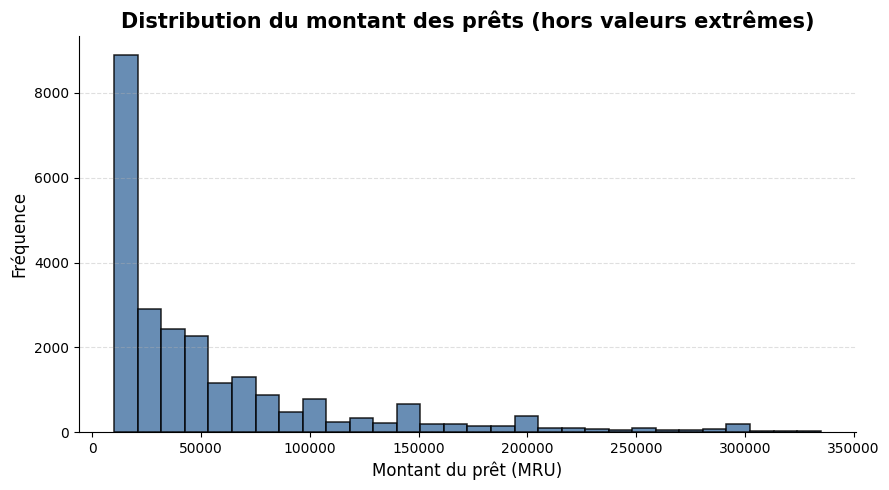

In [8]:
# Limiter l'affichage au 95e percentile
limite = df['MONTANT'].quantile(0.95)

data_montant = df[df['MONTANT'] <= limite]['MONTANT']

plt.figure(figsize=(9, 5))

plt.hist(
    data_montant,
    bins=30,
    color='#4E79A7',
    edgecolor='black',
    linewidth=1.1,
    alpha=0.85
)

plt.title('Distribution du montant des prêts (hors valeurs extrêmes)', fontsize=15, fontweight='bold')
plt.xlabel('Montant du prêt (MRU)', fontsize=12)
plt.ylabel('Fréquence', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

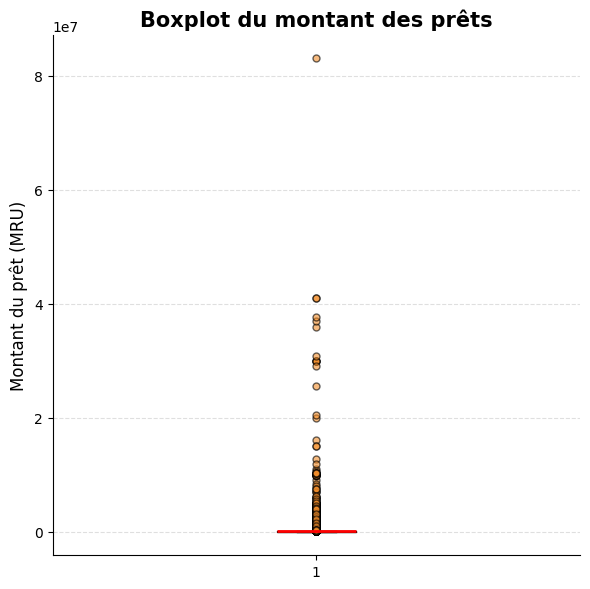

In [9]:
plt.figure(figsize=(6, 6))

plt.boxplot(
    df['MONTANT'].dropna(),
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor='#4E79A7', color='black'),
    medianprops=dict(color='red', linewidth=2),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    flierprops=dict(
        marker='o',
        markerfacecolor='#F28E2B',
        markeredgecolor='black',
        markersize=5,
        alpha=0.6
    )
)

plt.title('Boxplot du montant des prêts', fontsize=15, fontweight='bold')
plt.ylabel('Montant du prêt (MRU)', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Duree

In [10]:
df['DUREE'].describe()

count    25848.000000
mean        26.698081
std         14.148440
min          1.000000
25%          6.000000
50%         36.000000
75%         36.000000
max         96.000000
Name: DUREE, dtype: float64

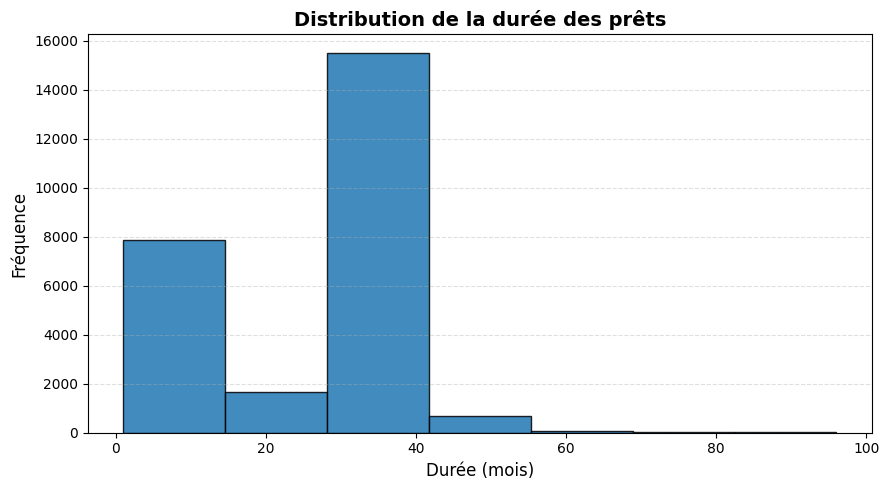

In [11]:
plt.figure(figsize=(9, 5))

plt.hist(
    df['DUREE'].dropna(),
    bins=7,
    edgecolor='black',
    alpha=0.85
)

plt.title("Distribution de la durée des prêts", fontsize=14, fontweight='bold')
plt.xlabel("Durée (mois)", fontsize=12)
plt.ylabel("Fréquence", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### PERIODE

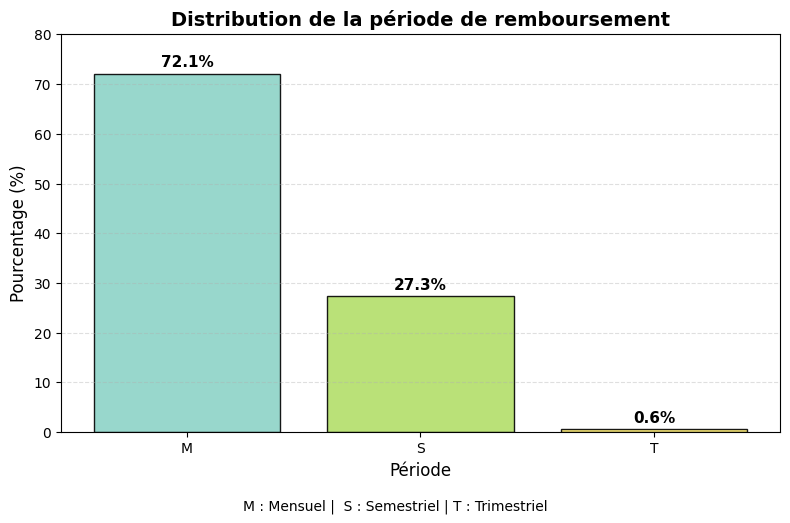

In [13]:
data = df['PERIODE'].value_counts(normalize=True).mul(100)

plt.figure(figsize=(8, 5))

colors = plt.cm.Set3(np.linspace(0, 1, len(data)))

bars = plt.bar(
    data.index,
    data.values,
    color=colors,
    edgecolor='black',
    alpha=0.9
)

# Add percentages on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.8,
        f"{height:.1f}%",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.title("Distribution de la période de remboursement", fontsize=14, fontweight='bold')
plt.xlabel("Période", fontsize=12)
plt.ylabel("Pourcentage (%)", fontsize=12)

plt.xticks(rotation=0)
plt.ylim(0, data.max() + 8)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.figtext(
    0.5, -0.03,
    "M : Mensuel |  S : Semestriel | T : Trimestriel",
    ha='center',
    fontsize=10
)

plt.tight_layout()
plt.show()

### TAUX_INT

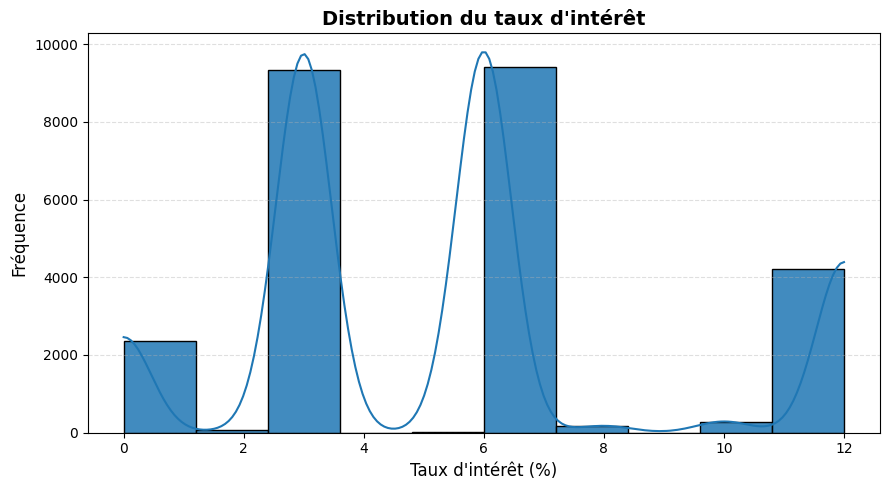

In [14]:
data = df['TAUX_INT'].dropna()

plt.figure(figsize=(9, 5))

sns.histplot(
    data,
    bins=10,
    kde=True,
    edgecolor='black',
    alpha=0.85
)

plt.title("Distribution du taux d'intérêt", fontsize=14, fontweight='bold')
plt.xlabel("Taux d'intérêt (%)", fontsize=12)
plt.ylabel("Fréquence", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### NBRE ECH

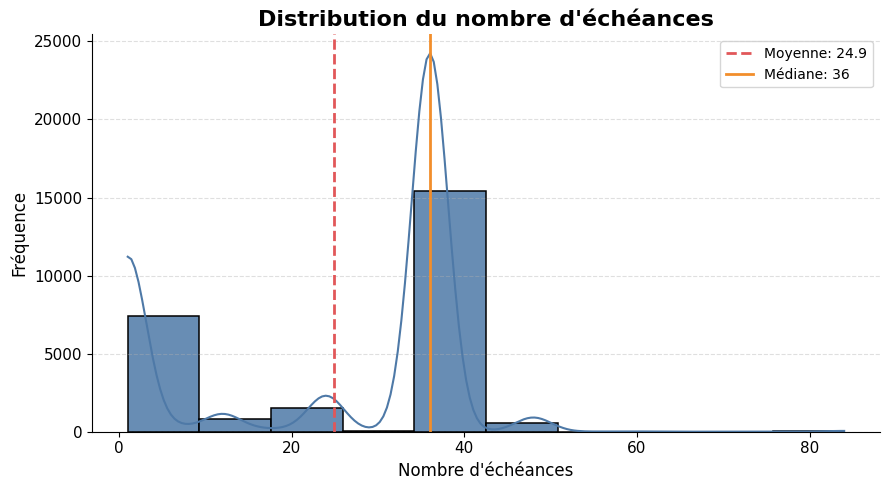

In [15]:
plt.figure(figsize=(9, 5))

ax = sns.histplot(
    df['NB_ECH'],
    bins=10,
    kde=True,
    color='#4E79A7',
    edgecolor='black',
    linewidth=1.1,
    alpha=0.85
)

# Moyenne et médiane
mean_nb_ech = df['NB_ECH'].mean()
median_nb_ech = df['NB_ECH'].median()

plt.axvline(
    mean_nb_ech,
    color='#E15759',
    linestyle='--',
    linewidth=2,
    label=f'Moyenne: {mean_nb_ech:.1f}'
)

plt.axvline(
    median_nb_ech,
    color='#F28E2B',
    linestyle='-',
    linewidth=2,
    label=f'Médiane: {median_nb_ech:.0f}'
)

# Personnalisation
plt.title("Distribution du nombre d'échéances", fontsize=16, fontweight='bold')
plt.xlabel("Nombre d'échéances", fontsize=12)
plt.ylabel("Fréquence", fontsize=12)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.legend(frameon=True)

# IMPORTANT: supprimer les lignes verticales
ax.grid(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Supprimer les bordures inutiles
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### SEXE

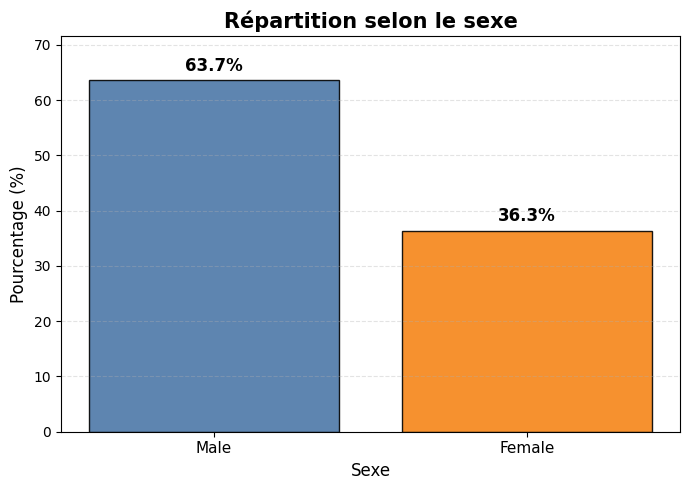

In [16]:
data = df['SEX'].value_counts(normalize=True).mul(100)

# Cool standard colors
colors = ['#4C78A8', '#F58518']  # blue + orange

plt.figure(figsize=(7, 5))

bars = plt.bar(
    data.index,
    data.values,
    color=colors[:len(data)],
    edgecolor='black',
    linewidth=1,
    alpha=0.9
)

# Add percentages on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.1f}%",
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

plt.title("Répartition selon le sexe", fontsize=15, fontweight='bold')
plt.xlabel("Sexe", fontsize=12)
plt.ylabel("Pourcentage (%)", fontsize=12)

plt.ylim(0, data.max() + 8)
plt.xticks(rotation=0, fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.35)
plt.tight_layout()
plt.show()

### VALEURGARANT

In [18]:
data = df['VALEURGARANT'].dropna()

plt.figure(figsize=(9, 5))

sns.histplot(
    data,
    bins=10,
    kde=True,
    edgecolor='black',
    alpha=0.85
)

plt.title("Distribution de la valeur de la garantie", fontsize=14, fontweight='bold')
plt.xlabel("Valeur de la garantie", fontsize=12)
plt.ylabel("Fréquence", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

KeyError: 'VALEURGARANT'

### IMPAYE & NBIMP

In [19]:
(df['IMPAYE'] == 0).sum() / (df['IMPAYE'].count())

np.float64(0.483983286908078)

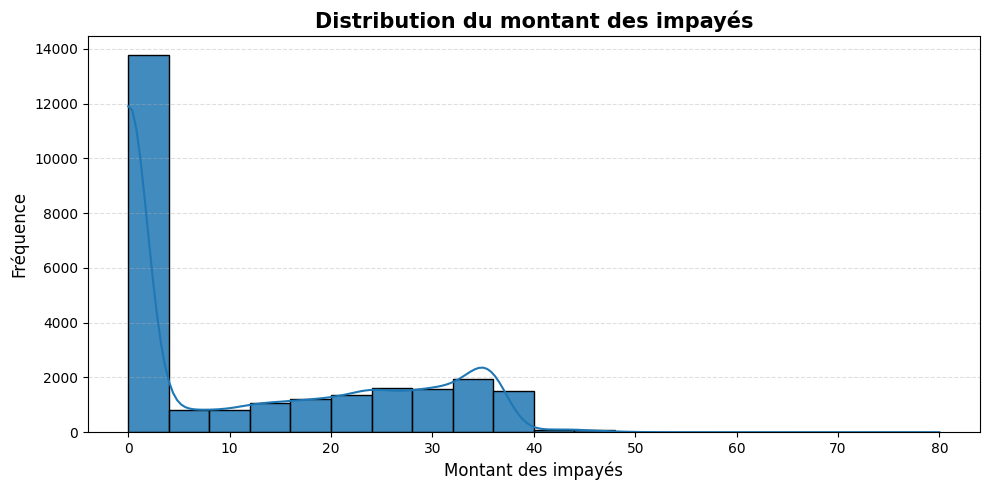

In [20]:
data = df['NBIMP'].dropna()

plt.figure(figsize=(10, 5))

sns.histplot(
    data,
    bins=20,
    kde=True,
    edgecolor='black',
    alpha=0.85
)

plt.title("Distribution du montant des impayés", fontsize=15, fontweight='bold')
plt.xlabel("Montant des impayés", fontsize=12)
plt.ylabel("Fréquence", fontsize=12)

# Format x-axis as money values
plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", " "))
)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [21]:
(df['NBIMP'] == 0).sum() / df.shape[0]

np.float64(0.483983286908078)

### MNTREMB

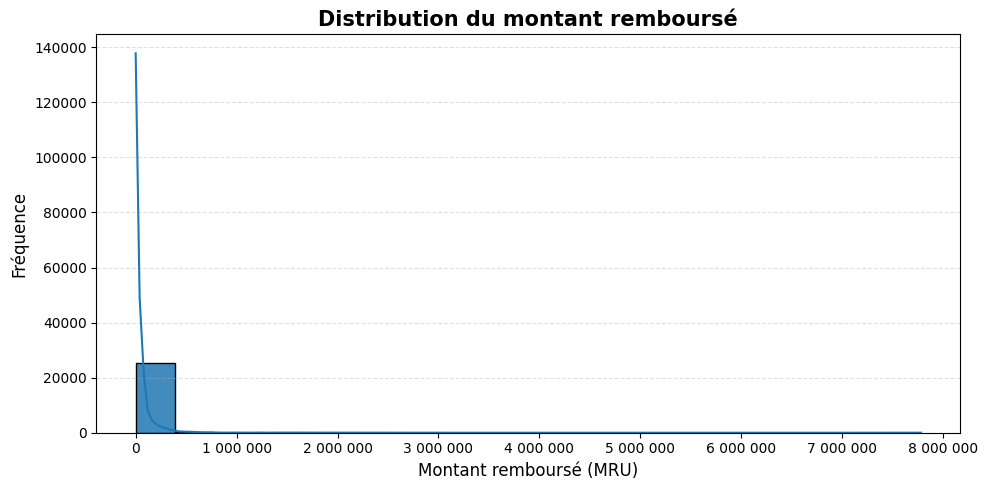

In [22]:
data = df['MNTREMB'].dropna()

plt.figure(figsize=(10, 5))

sns.histplot(
    data,
    bins=20,
    kde=True,
    edgecolor='black',
    alpha=0.85
)

plt.title("Distribution du montant remboursé", fontsize=15, fontweight='bold')
plt.xlabel("Montant remboursé (MRU)", fontsize=12)
plt.ylabel("Fréquence", fontsize=12)

# Format x-axis values with spaces
plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", " "))
)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### AGE

In [24]:
# Remove GROUP_AGE if it already exists
df = df.drop(columns=['GROUP_AGE'], errors='ignore')

# Create age groups
group_age = pd.cut(
    df['AGE'],
    bins=[0, 34, 44, 54, 64, 120],
    labels=['Moins de 35', '35-44', '45-54', '55-64', '65 et plus'],
    right=True
)

# Insert GROUP_AGE directly after AGE
pos = df.columns.get_loc('AGE') + 1
df.insert(pos, 'GROUP_AGE', group_age)

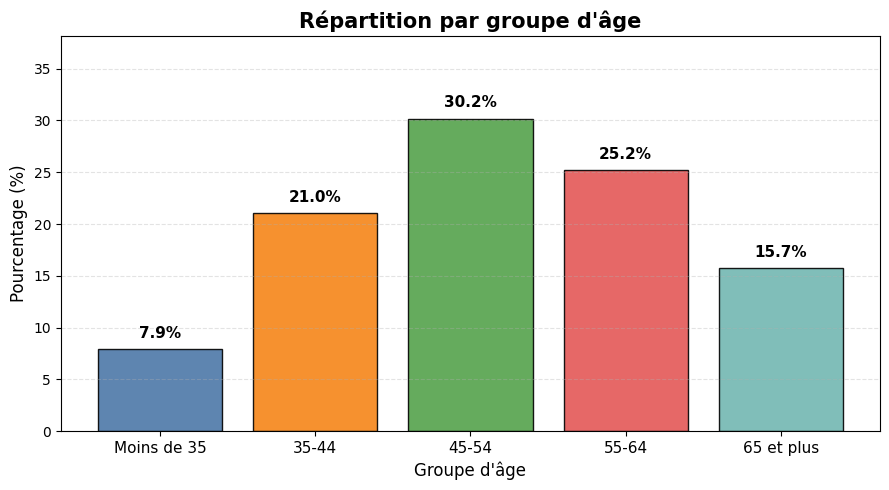

In [25]:
# Calculate percentages and keep the logical order of categories
ordre = ['Moins de 35', '35-44', '45-54', '55-64', '65 et plus']
data = (
    df['GROUP_AGE']
    .value_counts(normalize=True)
    .mul(100)
    .reindex(ordre)
)

# Clean and distinct colors
colors = ['#4C78A8', '#F58518', '#54A24B', '#E45756', '#72B7B2']

plt.figure(figsize=(9, 5))

bars = plt.bar(
    data.index,
    data.values,
    color=colors,
    edgecolor='black',
    linewidth=1,
    alpha=0.9
)

# Add percentages on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.8,
        f"{height:.1f}%",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.title("Répartition par groupe d'âge", fontsize=15, fontweight='bold')
plt.xlabel("Groupe d'âge", fontsize=12)
plt.ylabel("Pourcentage (%)", fontsize=12)

plt.xticks(rotation=0, fontsize=11)
plt.ylim(0, data.max() + 8)

plt.grid(axis='y', linestyle='--', alpha=0.35)
plt.tight_layout()
plt.show()

### ETAT CIVIL

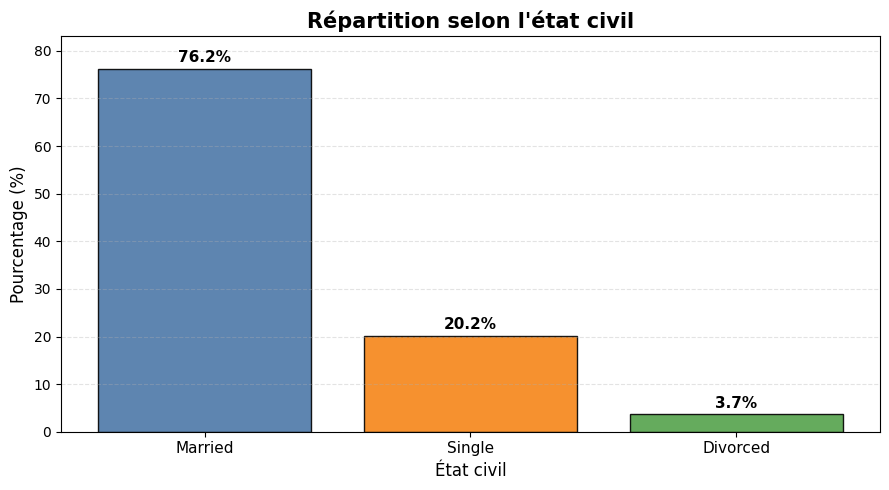

In [26]:
data = df['ETATCIVIL'].value_counts(normalize=True).mul(100)

# Cool standard colors
colors = ['#4C78A8', '#F58518', '#54A24B', '#E45756', '#72B7B2', '#B279A2']

plt.figure(figsize=(9, 5))

bars = plt.bar(
    data.index,
    data.values,
    color=colors[:len(data)],
    edgecolor='black',
    linewidth=1,
    alpha=0.9
)

# Percentages on top
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.8,
        f"{height:.1f}%",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.title("Répartition selon l'état civil", fontsize=15, fontweight='bold')
plt.xlabel("État civil", fontsize=12)
plt.ylabel("Pourcentage (%)", fontsize=12)

plt.xticks(rotation=0, fontsize=11)
plt.ylim(0, data.max() + 7)

plt.grid(axis='y', linestyle='--', alpha=0.35)
plt.tight_layout()
plt.show()

### WILAYA_NAISSANCE

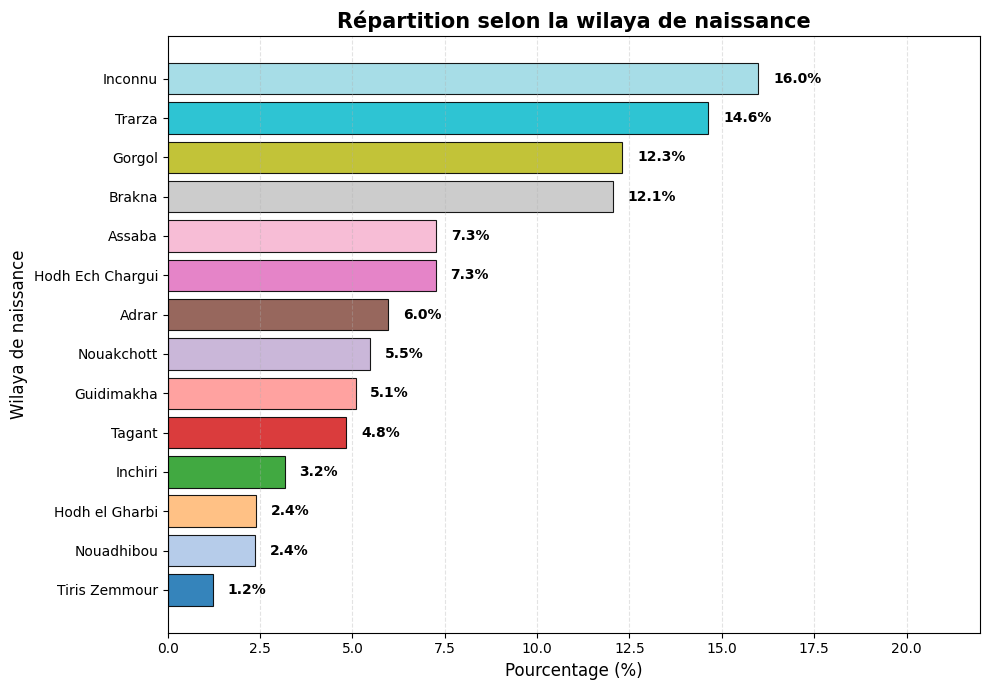

In [28]:
data = df['WILAYA_NAISSANCE'].value_counts(normalize=True).mul(100)

# Sort from largest to smallest
data = data.sort_values(ascending=True)

# Different colors for each bar
colors = plt.cm.tab20(np.linspace(0, 1, len(data)))

plt.figure(figsize=(10, 7))

bars = plt.barh(
    data.index,
    data.values,
    color=colors,
    edgecolor='black',
    linewidth=0.8,
    alpha=0.9
)

# Add percentages
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.4,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title("Répartition selon la wilaya de naissance", fontsize=15, fontweight='bold')
plt.xlabel("Pourcentage (%)", fontsize=12)
plt.ylabel("Wilaya de naissance", fontsize=12)

plt.xlim(0, data.max() + 6)
plt.grid(axis='x', linestyle='--', alpha=0.35)

plt.tight_layout()
plt.show()

### TYPE_CLIENT

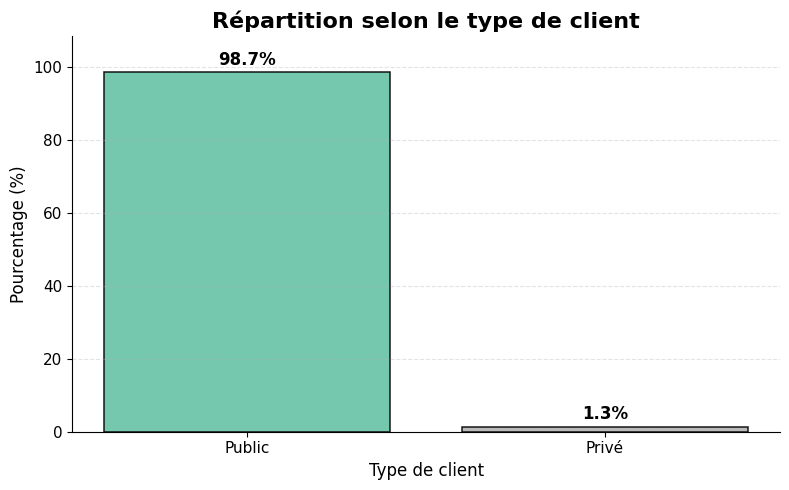

In [29]:
# Calcul des pourcentages
data = (
    df['TYPE_CLIENT']
    .value_counts(normalize=True)
    .mul(100)
    .sort_values(ascending=False)
)

# Couleurs professionnelles
colors = plt.cm.Set2(np.linspace(0, 1, len(data)))

# Création du graphique
plt.figure(figsize=(8, 5))

bars = plt.bar(
    data.index,
    data.values,
    color=colors,
    edgecolor='black',
    linewidth=1.1,
    alpha=0.90
)

ax = plt.gca()

# Ajouter les pourcentages au-dessus des barres
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

# Personnalisation
plt.title("Répartition selon le type de client", fontsize=16, fontweight='bold')
plt.xlabel("Type de client", fontsize=12)
plt.ylabel("Pourcentage (%)", fontsize=12)

plt.ylim(0, data.max() + 10)
plt.xticks(rotation=0, fontsize=11)
plt.yticks(fontsize=11)

# Supprimer les lignes verticales et garder seulement les lignes horizontales
ax.grid(False)
ax.grid(axis='y', linestyle='--', alpha=0.35)

# Supprimer les bordures inutiles
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### DEFAUT (target variable)

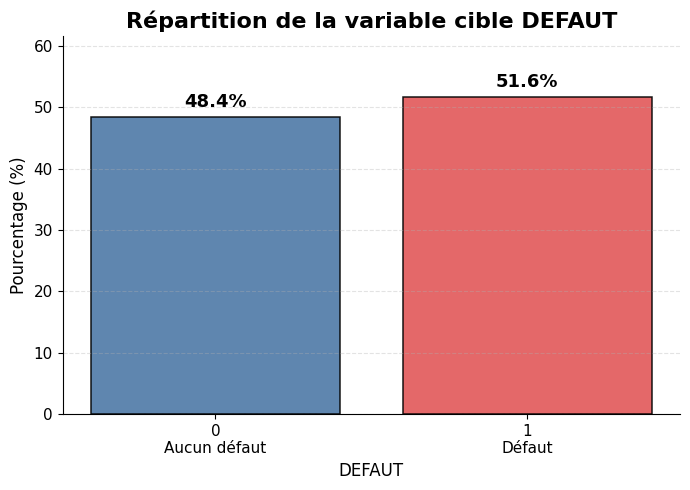

In [30]:
# Calcul des pourcentages
data = (
    df['DEFAUT']
    .value_counts(normalize=True)
    .mul(100)
    .sort_index()
)

# Création du graphique
plt.figure(figsize=(7, 5))

colors = ['#4E79A7', '#E15759']

bars = plt.bar(
    data.index.astype(str),   # garder 0 et 1 dans le graphique
    data.values,
    color=colors,
    edgecolor='black',
    linewidth=1.1,
    alpha=0.90
)

ax = plt.gca()

# Ajouter les pourcentages au-dessus des barres
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=13,
        fontweight='bold'
    )

# Personnalisation
plt.title("Répartition de la variable cible DEFAUT", fontsize=16, fontweight='bold')
plt.xlabel("DEFAUT", fontsize=12)
plt.ylabel("Pourcentage (%)", fontsize=12)

plt.xticks(
    ticks=[0, 1],
    labels=[
        "0\nAucun défaut",
        "1\nDéfaut"
    ],
    fontsize=11
)

plt.yticks(fontsize=11)
plt.ylim(0, data.max() + 10)

# Grille propre
ax.grid(False)
ax.grid(axis='y', linestyle='--', alpha=0.35)

# Supprimer les bordures inutiles
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()